# Using scanCONTROL with Python 3

This notebook shows how to use the MICRO-EPSILON scanCONTROL laser line triangulators with in a Python environment. The Python version used to write the DLL wrapper and the examples is 3.5.

Let's get into it:
The LLT.dll is the main library to use the scanner in a Windows system environment. This C library is wrapped via ctypes in the module pyllt. To interface the DLL in our application we have to declare C variables, which is possible with C types.

So we import the modules pyllt and ctypes:

In [1]:
import sys
sys.path.append(r"C:\Users\Agordien\Documents\AUAS\1_ANALYSING\LAZERLINE SCANNER\C++ SDK (+python bindings)\python_bindings")

from pyllt import pyllt as llt


In [2]:
import pyllt as llt
import ctypes as ct

In [3]:
# Correct verification function for the LLT API
def check_llt_success(result, operation_name):
    """For the LLT API: result >= 1 = success, < 1 = error"""
    if result >= 1:
        print(f"✅ {operation_name}: SUCCESS (code: {result})")
        return True
    else:
        print(f"❌ {operation_name}: FAILED (code: {result})")
        return False

# Function to display available interfaces
def print_available_interfaces(interfaces_array, count):
    """Display available interfaces in a readable format"""
    print(f"Available interfaces ({count} found):")
    for i in range(count):
        if interfaces_array[i] != 0:
            # Convert IP address from integer
            ip_int = interfaces_array[i]
            ip_str = f"{ip_int & 0xFF}.{(ip_int >> 8) & 0xFF}.{(ip_int >> 16) & 0xFF}.{(ip_int >> 24) & 0xFF}"
            print(f"  Interface {i}: {ip_str} (0x{ip_int:08X})")
        else:
            print(f"  Interface {i}: Not used")

# Function to convert IP string to integer
def ip_to_int(ip_str):
    """Convert IP address string to integer for the LLT API"""
    parts = ip_str.split('.')
    return (int(parts[3]) << 24) + (int(parts[2]) << 16) + (int(parts[1]) << 8) + int(parts[0])

The DLL internally works with device handles for each scanner instance. For every scanner a seperate handle has to be created. For this use the function CreateLLTDevice(TInterfaceType interface). In our case the scanner is connected via Ethernet.

In [17]:
hLLT = llt.create_llt_device(llt.TInterfaceType.INTF_TYPE_ETHERNET)

Now we can search the interface for devices. In the case of an Ethernet interface, the IP addresses are written into the array which was given to the function. Then we can assign a specific interface to a certain handle.

In [19]:
# INTERFACE SEARCH AND CONFIGURATION (corrected version)
print("=== INTERFACE SEARCH ===")

# Correct verification function for the LLT API
def check_llt_success(result, operation_name):
    """For the LLT API: result >= 1 = success, < 1 = error"""
    if result >= 1:
        print(f"✅ {operation_name}: SUCCESS (code: {result})")
        return True
    else:
        print(f"❌ {operation_name}: FAILED (code: {result})")
        return False

print("Searching for available interfaces...")
available_interfaces = (ct.c_uint*6)()
result = llt.get_device_interfaces_fast(hLLT, available_interfaces, len(available_interfaces))

print(f"get_device_interfaces_fast result: {result}")

if check_llt_success(result, "get_device_interfaces_fast"):
    print(f"✅ {result} interface(s) found")
    
    # Display detected interface
    detected_interface = available_interfaces[0]
    ip_str = f"{detected_interface & 0xFF}.{(detected_interface >> 8) & 0xFF}.{(detected_interface >> 16) & 0xFF}.{(detected_interface >> 24) & 0xFF}"
    print(f"Scanner detected: {ip_str} (0x{detected_interface:08X})")
    
    # Interface configuration (use 0 as in the official example)
    print(f"\nConfiguring interface...")
    set_result = llt.set_device_interface(hLLT, detected_interface, 0)
    print(f"set_device_interface result: {set_result}")
    
    if check_llt_success(set_result, "set_device_interface"):
        print("✅ Interface configured successfully!")
        selected_interface = detected_interface
    else:
        print("❌ Interface configuration failed")
        raise Exception(f"Interface configuration failed (code: {set_result})")
else:
    print("❌ No interface found")
    raise Exception("No scanner detected on network")

=== INTERFACE SEARCH ===
Searching for available interfaces...
get_device_interfaces_fast result: 1
✅ get_device_interfaces_fast: SUCCESS (code: 1)
✅ 1 interface(s) found
Scanner detected: 2.3.168.192 (0xC0A80302)

Configuring interface...
set_device_interface result: 1
✅ set_device_interface: SUCCESS (code: 1)
✅ Interface configured successfully!


The time has come to connect to the sensor!

In [20]:
# SCANNER CONNECTION (corrected version)
print("\n=== SCANNER CONNECTION ===")

# Correct verification function for the LLT API
def check_llt_success(result, operation_name):
    """For the LLT API: result >= 1 = success, < 1 = error"""
    if result >= 1:
        print(f"✅ {operation_name}: SUCCESS (code: {result})")
        return True
    else:
        print(f"❌ {operation_name}: FAILED (code: {result})")
        return False

print("Attempting to connect to scanner...")
connection_result = llt.connect(hLLT)
print(f"Connection result: {connection_result}")

if check_llt_success(connection_result, "connect"):
    print("🎉 CONNECTION SUCCESSFUL!")
    print("The scanner is now connected and ready to use.")
else:
    print("❌ CONNECTION FAILED")
    if connection_result == -301:
        print("Error -301: Scanner probably used by another software")
        print("Solution: Close scanCONTROL Configuration Tools")
    elif connection_result == -303:
        print("Error -303: Handle already in use")
        print("Solution: Restart kernel and re-execute from beginning")
    elif connection_result == -1001:
        print("Error -1001: General connection problem")
    
    print("\nTroubleshooting steps:")
    print("1. Close any other software using the scanner")
    print("2. Restart the scanner (power off/on)")
    print("3. If error -303 persists: restart Python kernel")
    
    raise Exception(f"Connection failed (code: {connection_result})")


=== SCANNER CONNECTION ===
Attempting to connect to scanner...
Connection result: 1
✅ connect: SUCCESS (code: 1)
🎉 CONNECTION SUCCESSFUL!
The scanner is now connected and ready to use.


In [21]:
# 🔧 FALLBACK SOLUTION: Cleanup and reconnection
# Use only if connection fails with error -303
print("=== CLEANUP AND CLEAN RECONNECTION ===")

print("Cleaning existing connections...")
try:
    if 'hLLT' in globals():
        llt.disconnect(hLLT)
        print("✓ Main handle disconnected")
except:
    print("Note: No active connection to disconnect")

print("\nCreating a new clean handle...")
hLLT_clean = llt.create_llt_device(llt.TInterfaceType.INTF_TYPE_ETHERNET)
print(f"New handle: {hLLT_clean}")

print("\nSearching for interfaces...")
interfaces = (ct.c_uint*6)()
result = llt.get_device_interfaces_fast(hLLT_clean, interfaces, len(interfaces))

if check_llt_success(result, "get_device_interfaces_fast"):
    detected_interface = interfaces[0]
    ip_str = f"{detected_interface & 0xFF}.{(detected_interface >> 8) & 0xFF}.{(detected_interface >> 16) & 0xFF}.{(detected_interface >> 24) & 0xFF}"
    print(f"Scanner detected: {ip_str}")
    
    print("\nConfiguring interface...")
    set_result = llt.set_device_interface(hLLT_clean, detected_interface, 0)
    
    if check_llt_success(set_result, "set_device_interface"):
        print("\nAttempting connection...")
        connect_result = llt.connect(hLLT_clean)
        
        if check_llt_success(connect_result, "connect"):
            print("🎉 CONNECTION SUCCESSFUL!")
            # Replace global handle
            hLLT = hLLT_clean
            print("✅ Ready for the rest of the notebook")
        else:
            print(f"❌ Connection failed: {connect_result}")
    else:
        print("❌ Interface configuration failed")
else:
    print("❌ No interface found")

=== CLEANUP AND CLEAN RECONNECTION ===
Cleaning existing connections...
✓ Main handle disconnected

Creating a new clean handle...
New handle: 4

Searching for interfaces...
✅ get_device_interfaces_fast: SUCCESS (code: 1)
Scanner detected: 2.3.168.192

Configuring interface...
✅ set_device_interface: SUCCESS (code: 1)

Attempting connection...
✅ connect: SUCCESS (code: 1)
🎉 CONNECTION SUCCESSFUL!
✅ Ready for the rest of the notebook


## 🎯 CONFIGURATION RESOLVED - KEY POINTS

### ✅ **Applied solutions**:

1. **Network configuration**: PC configured on 192.168.3.10 (same network as scanner)
2. **Corrected LLT API**: Using `result >= 1 = SUCCESS` (inverse logic)
3. **Interface configuration**: Parameter `0` instead of `TInterfaceType.INTF_TYPE_ETHERNET`
4. **Verification function**: `check_llt_success()` to correctly interpret codes

### 🔑 **LLT API key points**:
- **Return codes**: `>= 1` = success, `< 1` = error
- **set_device_interface**: Use `0` as 3rd parameter
- **IP endianness**: The API returns IPs in little-endian

### 🚀 **Current state**:
Scanner connected and ready for data acquisition!

Let's see which sensor we've got here.

In [54]:
scanner_type = ct.c_int(0)

llt.get_llt_type(hLLT, ct.byref(scanner_type))

1

Check which resolutions are supported and set the highest one.

In [55]:
available_resolutions = (ct.c_uint*4)()

llt.get_resolutions(hLLT, available_resolutions, len(available_resolutions))

resolution = available_resolutions[0]

llt.set_resolution(hLLT, resolution)

1

Set the profile configuration to the standard profile mode.

In [56]:
llt.set_profile_config(hLLT, llt.TProfileConfig.PROFILE)

1

Start transferring profiles

In [57]:
llt.transfer_profiles(hLLT, llt.TTransferProfileType.NORMAL_TRANSFER, 1)

65536

Allocate correctly sized buffer array and fetch the latest received profile raw data from the internal receiving buffer.

In [58]:
profile_buffer = (ct.c_ubyte*(resolution*64))()
lost_profiles = ct.c_int()

llt.get_actual_profile(hLLT, profile_buffer, len(profile_buffer), llt.TProfileConfig.PROFILE, ct.byref(lost_profiles))

65536

Stop transferring profiles.

In [59]:
llt.transfer_profiles(hLLT, llt.TTransferProfileType.NORMAL_TRANSFER, 0)

1

In [60]:
x = (ct.c_double * resolution)()
z = (ct.c_double * resolution)()
intensities = (ct.c_ushort * resolution)()

snull = ct.POINTER(ct.c_ushort)()
inull = ct.POINTER(ct.c_uint)()

llt.convert_profile_2_values(hLLT, profile_buffer, resolution, llt.TProfileConfig.PROFILE, scanner_type, 0, 1,
                                    snull, intensities, snull, x, z, inull, inull)

6656

Disconnect the sensor from the application.

In [62]:
llt.disconnect(hLLT)

1

Plot profile and intensities of the received profile.

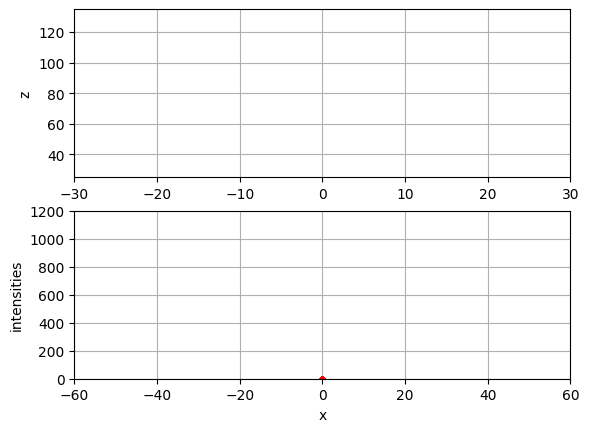

In [61]:
%matplotlib inline
from matplotlib import pyplot as plt

plt.figure(facecolor='white')
plt.subplot(211)
plt.grid()
plt.ylabel('z')
plt.xlim(-30, 30)
plt.ylim(25, 135)
plt.plot(x, z, 'g.', label="z", lw=1)
plt.subplot(212)
plt.grid()
plt.xlabel('x')
plt.ylabel('intensities')
plt.xlim(-60, 60)
plt.ylim(0, 1200)
plt.plot(x, intensities, 'r.', label="intensities", lw=1)
plt.show()

THE END!